### Flow map
Now that we have a grid over the $(a,b)$-plane we can visualize the loss landscape. Below the red dot represents the base parameterization from which all other points are reweighed from. The green start is the target parameterization where the loss function (in this case the psuedo-$\chi^2$) should be at a minimum. The arrow represent the gradients of $a$ and $b$ at each grid point.

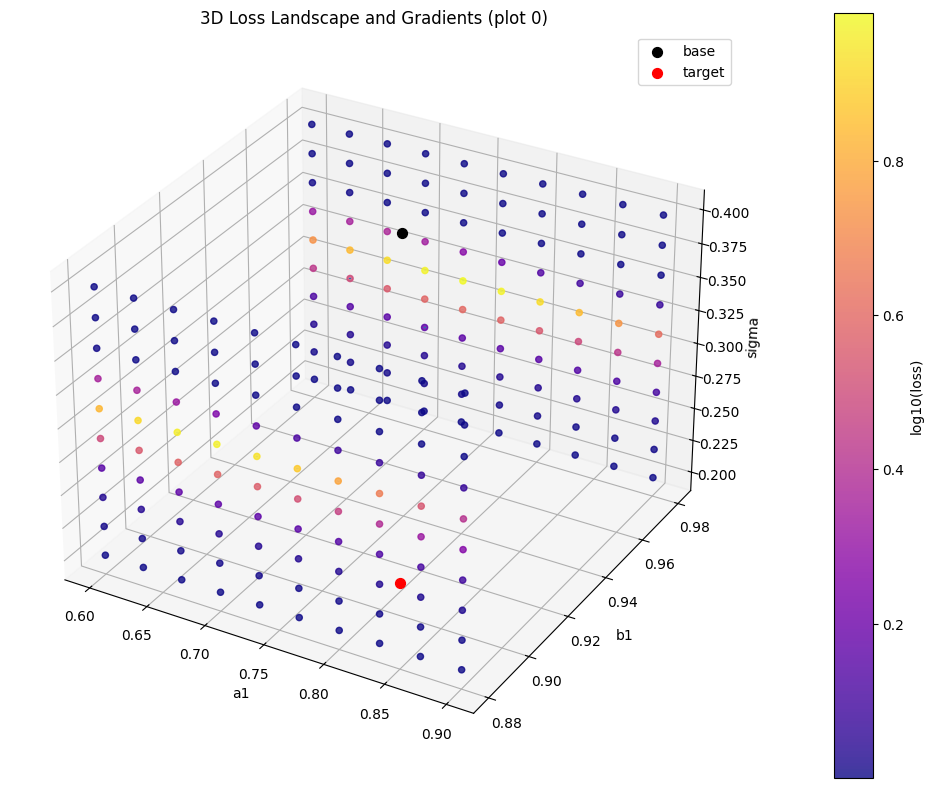

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -- Load data for the chosen plot --
plot_nm = '0'
gradients     = np.load(f'temp_results/Flow_map/3D/gradients_{plot_nm}.npy')
magnitudes    = np.load(f'temp_results/Flow_map/3D/magnitudes_{plot_nm}.npy')
loss_grid     = np.load(f'temp_results/Flow_map/3D/loss_grid_{plot_nm}.npy')
mu_sigmamu    = np.load(f'temp_results/Flow_map/3D/mu_{plot_nm}.npy')
Neff          = np.load(f'temp_results/Flow_map/3D/Neff_{plot_nm}.npy')
mu, sigmamu   = mu_sigmamu[:, 0], mu_sigmamu[:, 1]
params_grid   = np.load(f'temp_results/Flow_map/3D/params_grid_{plot_nm}.npy')
ordered_params = np.load(f'temp_results/Flow_map/3D/ordered_params_{plot_nm}.npy')


# Configuration per plot_nm: scale and base/target points
plot3d_configs = {
    '0': {'scale': 3e3, 'base': (0.68, 0.98, 0.335), 'target': (0.85, 0.88, 0.25)},
    '1': {'scale': 3e3, 'base': (0.68, 0.98, 0.335), 'target': (0.85, 0.88, 0.25)},
}
config = plot3d_configs.get(plot_nm)
if config is None:
    raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# Unpack coordinates and gradients
p1, p2, p3 = params_grid[:, 0], params_grid[:, 1], params_grid[:, 2]
g1, g2, g3  = -gradients[:, 0], -gradients[:, 1], -gradients[:, 2]

# Create 3D figure
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

# Plot base and target
ax.scatter(*config['base'],  marker='o', color='black', s=50, label='base')
ax.scatter(*config['target'], marker='o', color='red',   s=50, label='target')

# Quiver for gradient field
ax.quiver(p1, p2, p3,
          g1 / config['scale'],
          g2 / config['scale'],
          g3 / config['scale'],
          length=1.0, normalize=False)

# Scatter colored by loss value
sc = ax.scatter(p1, p2, p3,
                # c=np.log10(loss_grid), cmap='plasma',
                c=Neff, cmap='plasma',
                s=20, alpha=0.8)
cbar = fig.colorbar(sc, pad=0.1)
cbar.set_label('log10(loss)')

# Labels and legend
ax.set_xlabel(f'{ordered_params[0]}')
ax.set_ylabel(f'{ordered_params[1]}')
ax.set_zlabel(f'{ordered_params[2]}')
ax.set_title(f'3D Loss Landscape and Gradients (plot {plot_nm})')
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Configuration per plot_nm: scale, head_width, head_length, base (a,b,sigma), target (a,b,sigma)
# plot_configs = {
#     '0':{'scale':5e3,'head_width':0.004,'head_length':0.003,'base':{'a':0.68 + 0.0425,'b':0.955,'sigma':0.31375},'target':{'a':0.85,'b':0.88,'sigma':0.25}},
#     '72':{'scale':5e3,'head_width':0.004,'head_length':0.003,'base':{'a':0.68 + 0.0425,'b':0.955,'sigma':0.31375},'target':{'a':0.85,'b':0.88,'sigma':0.25}},
# }
# config = plot_configs.get(plot_nm)
# if config is None:
#     raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# # Metrics to display
# metrics = {
#     'loss': {'values': lambda: np.log10(loss_grid), 'label': 'log10(loss)'},
#     'mu':   {'values': lambda: mu,               'label': r"$\ln\left|\frac{1-\mu}{\sigma_{1-\mu}}\right|$"},
#     'Neff': {'values': lambda: Neff,             'label': 'Neff'},
# }

# # Unique bd values to slice
# bds = np.unique(a_b_c[:,1])

# for metric_key, metric in metrics.items():
#     vals = metric['values']()
#     for bd_val in bds:
#         mask = (a_b_c[:,1] == bd_val)
#         ad_vals = a_b_c[mask,0]
#         au_vals = a_b_c[mask,2]
#         grads   = a_b_gradients[mask]
#         m_vals  = vals[mask]

#         # Build grid
#         ad_u = np.unique(ad_vals)
#         au_u = np.unique(au_vals)
#         A, U = np.meshgrid(ad_u, au_u, indexing='ij')
#         Z    = m_vals.reshape(len(ad_u), len(au_u))

#         # Plot
#         plt.figure(figsize=(6,5))
#         pcm = plt.pcolormesh(A, U, Z, shading='auto', cmap='plasma')
#         plt.colorbar(pcm, label=metric['label'])

#         # Gradient arrows
#         for (x,y), g in zip(np.vstack([ad_vals, au_vals]).T, grads):
#             dx = -g[0] / config['scale']
#             dy = -g[2] / config['scale']
#             plt.arrow(x, y, dx, dy,
#                       head_width=config['head_width'],
#                       head_length=config['head_length'],
#                       fc='k', ec='k', linewidth=0.7)

#         # Base and target markers
#         base = config['base']
#         tgt  = config['target']
#         plt.plot(base['a'], base['sigma'], 'o', color='black', markersize=6, label='base')
#         plt.plot(tgt['a'],  tgt['sigma'],'o', color='red',   markersize=6, label='target')

#         # Title uses base/target b and sigma
#         title = (
#             f"Metric={metric_key} | b_d={bd_val:.3f}\n"
#             f"base: a={base['a']}, b={base['b']}, sigma={base['sigma']}\n"
#             f"target: a={tgt['a']}, b={tgt['b']}, sigma={tgt['sigma']}"
#         )
#         plt.title(title)
#         plt.xlabel('a_d')
#         plt.ylabel('sigma')
#         plt.legend(loc='lower left')
#         plt.tight_layout()
#         # if bd_val.round(3) == 0.878 or bd_val.round(3) == 0.967:
#             # plt.savefig(f'temp_results/Flow_map_nD/plots/{plot_nm}_{metric_key}_bd_{bd_val:.3f}.png', dpi=300)
#         plt.savefig(f'temp_results/Flow_map_nD/plots/{plot_nm}_{metric_key}_bd_{bd_val:.3f}.png', dpi=300)


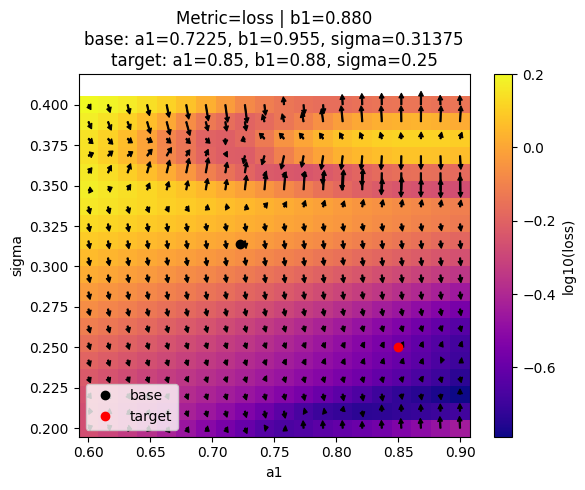

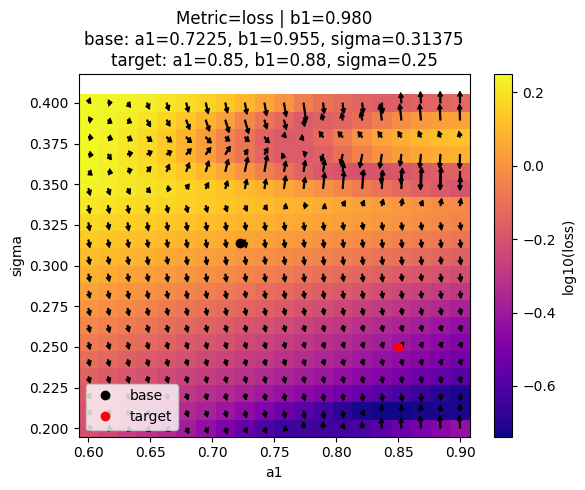

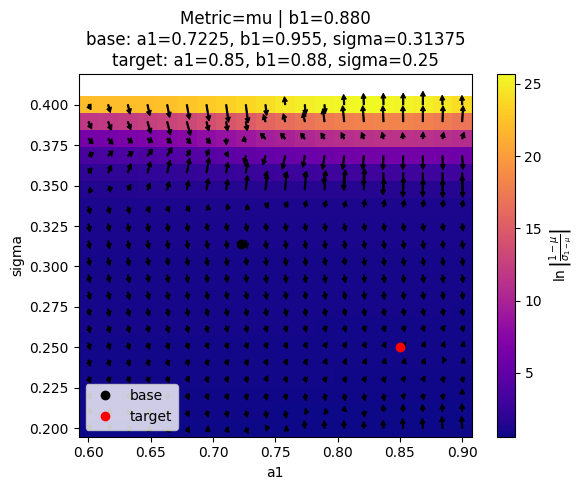

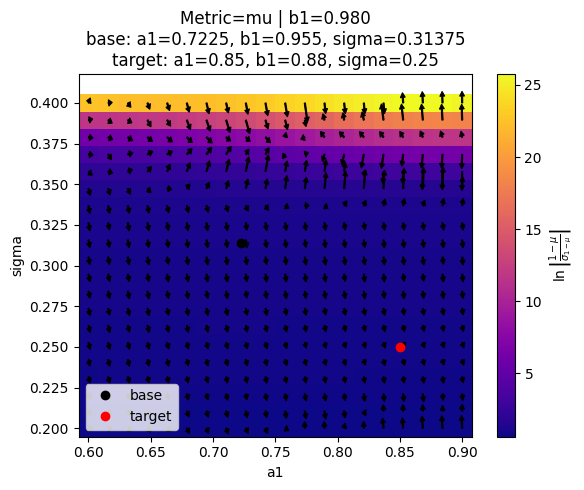

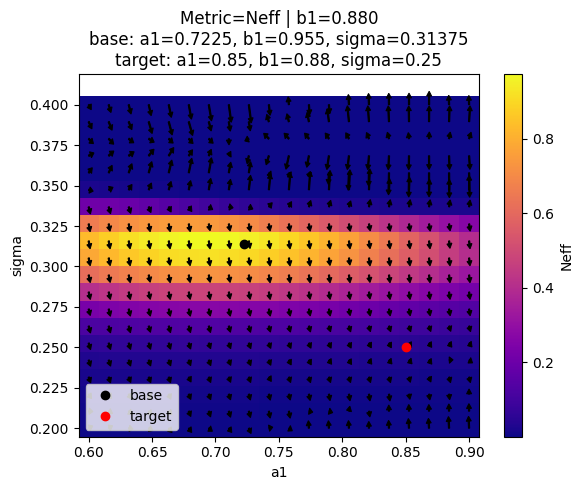

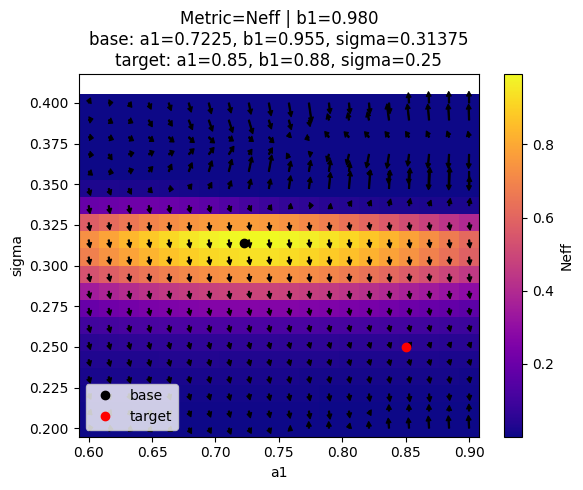

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -- Load data for the chosen plot --
plot_nm = '1'
gradients     = np.load(f'temp_results/Flow_map/3D/gradients_{plot_nm}.npy')
loss_grid     = np.load(f'temp_results/Flow_map/3D/loss_grid_{plot_nm}.npy')
mu_sigmamu    = np.load(f'temp_results/Flow_map/3D/mu_{plot_nm}.npy')
Neff          = np.load(f'temp_results/Flow_map/3D/Neff_{plot_nm}.npy')
params_grid   = np.load(f'temp_results/Flow_map/3D/params_grid_{plot_nm}.npy')
ordered_params = np.load(f'temp_results/Flow_map/3D/ordered_params_{plot_nm}.npy')

# Unpack weight metrics
mu, sigmamu = mu_sigmamu[:, 0], mu_sigmamu[:, 1]

# Configuration per plot_nm: scale, arrow head sizes, base & target points
plot3d_configs = {
    '0': {'scale':      5e3, 'head_width': 0.004, 'head_length':0.003, 'base':   (0.68 + 0.0425, 0.955, 0.31375), 'target': (0.85,         0.88,  0.25)},
    '1': {'scale':      5e3, 'head_width': 0.004, 'head_length':0.003, 'base':   (0.68 + 0.0425, 0.955, 0.31375), 'target': (0.85,         0.88,  0.25)},
}
config = plot3d_configs.get(plot_nm)
if config is None:
    raise ValueError(f"Unsupported plot_nm: {plot_nm}")

# Metrics to display
metrics = {
    'loss': {'values': lambda: np.log10(loss_grid), 'label': 'log10(loss)'},
    'mu':   {'values': lambda: mu,                  'label': r"$\ln\left|\frac{1-\mu}{\sigma_{1-\mu}}\right|$"},
    'Neff': {'values': lambda: Neff,                'label': 'Neff'},
}

# Prepare output folder
out_folder = 'temp_results/Flow_map_nD/plots'
os.makedirs(out_folder, exist_ok=True)

# Slice along the middle parameter (bd = params_grid[:,1])
bds = np.unique(params_grid[:,1])

for metric_key, metric in metrics.items():
    vals = metric['values']()
    for bd_val in bds:
        mask    = (params_grid[:,1] == bd_val)
        p1_vals = params_grid[mask, 0]   # a_d
        p3_vals = params_grid[mask, 2]   # sigma
        grads   = gradients[mask]
        m_vals  = vals[mask]

        # Build rectangular grid in (a_d, sigma)
        a_u     = np.unique(p1_vals)
        s_u     = np.unique(p3_vals)
        A, S    = np.meshgrid(a_u, s_u, indexing='ij')
        Z       = m_vals.reshape(len(a_u), len(s_u))

        # Plot heatmap
        plt.figure(figsize=(6,5))
        pcm = plt.pcolormesh(A, S, Z, shading='auto', cmap='plasma')
        plt.colorbar(pcm, label=metric['label'])

        # Overlay gradient arrows (negative = descent direction)
        for (x, z), g in zip(np.vstack([p1_vals, p3_vals]).T, grads):
            dx = -g[0] / config['scale']
            dz = -g[2] / config['scale']
            plt.arrow(x, z, dx, dz,
                      head_width=config['head_width'],
                      head_length=config['head_length'],
                      fc='k', ec='k', linewidth=0.7)

        # Mark base & target
        bx, by, bz = config['base']
        tx, ty, tz = config['target']
        plt.plot(bx, bz, 'o', color='black', markersize=6, label='base')
        plt.plot(tx, tz, 'o', color='red',   markersize=6, label='target')

        # Titles and labels
        title = (
            f"Metric={metric_key} | {ordered_params[1]}={bd_val:.3f}\n"
            f"base: {ordered_params[0]}={bx}, {ordered_params[1]}={by}, {ordered_params[2]}={bz}\n"
            f"target: {ordered_params[0]}={tx}, {ordered_params[1]}={ty}, {ordered_params[2]}={tz}"
        )
        plt.title(title)
        plt.xlabel(ordered_params[0])
        plt.ylabel(ordered_params[2])
        plt.legend(loc='lower left')
        plt.tight_layout()

        # Save
        # fname = f'{plot_nm}_{metric_key}_bd_{bd_val:.3f}.png'
        # plt.savefig(os.path.join(out_folder, fname), dpi=300)
        # plt.close()
# print(Z)
# print(dx,dz)